In [1]:
import pandas as pd
email_class_df = pd.read_csv('../data/new datasset + classifications/spam_Emails_data.csv')

email_class_df.describe()
email_class_df.info()
email_class_df.head(5)

<class 'pandas.DataFrame'>
RangeIndex: 193852 entries, 0 to 193851
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   label   193852 non-null  str  
 1   text    193850 non-null  str  
dtypes: str(2)
memory usage: 3.0 MB


,label,text
0,Spam,viiiiiiagraaaa\nonly for the ones that want to...
1,Ham,got ice thought look az original message ice o...
2,Spam,yo ur wom an ne eds an escapenumber in ch ma n...
3,Spam,start increasing your odds of success & live s...
4,Ham,author jra date escapenumber escapenumber esca...


In [2]:
# drop null text
email_class_df = email_class_df.dropna()
email_class_df.describe()
email_class_df.info()

<class 'pandas.DataFrame'>
Index: 193850 entries, 0 to 193851
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   label   193850 non-null  str  
 1   text    193850 non-null  str  
dtypes: str(2)
memory usage: 4.4 MB


In [3]:
# see distinct labels email class
email_class = email_class_df['label'].value_counts()
print(email_class)

label
Ham     102159
Spam     91691
Name: count, dtype: int64


In [4]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = email_class_df['text'], email_class_df['label'] # Separate text and labels
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define the Pipeline
text_clf = Pipeline([
    ('vect', CountVectorizer(stop_words='english')), # Tokenize and count
    ('tfidf', TfidfTransformer()),                   # Step 2: Apply TF-IDF weighting
    ('clf', MultinomialNB(alpha=1.0))                # Step 3: Classifier with Laplace smoothing
])

# Train the entire Pipeline
# You only need to call .fit() once; it handles all three steps internally
text_clf.fit(X_train, y_train)

# Predict and Evaluate
y_pred = text_clf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")

Accuracy: 0.96


--- Basic Metrics ---
Accuracy:  0.96
Precision: 0.99
Recall:    0.93
F1-Score:  0.96

--- Detailed Classification Report ---
              precision    recall  f1-score   support

         Ham       0.94      0.99      0.97     30566
        Spam       0.99      0.93      0.96     27589

    accuracy                           0.96     58155
   macro avg       0.97      0.96      0.96     58155
weighted avg       0.96      0.96      0.96     58155


--- Confusion Matrix ---
[[30236   330]
 [ 1819 25770]]


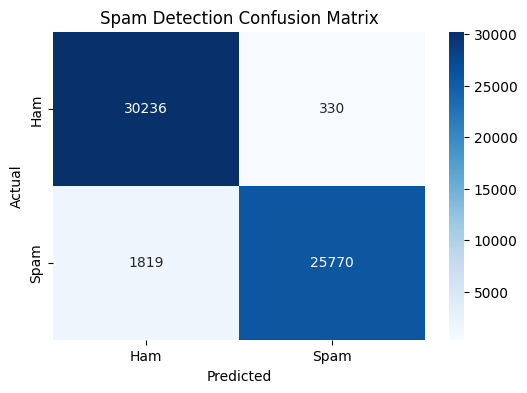

In [5]:
# DETAILED EVALUATION

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    confusion_matrix, 
    classification_report
)

email_class = text_clf.classes_  # dynamic email classes

print("--- Basic Metrics ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.2f}")
# pos_label is needed for binary classification metrics
print(f"Precision: {precision_score(y_test, y_pred, pos_label='Spam'):.2f}")
print(f"Recall:    {recall_score(y_test, y_pred, pos_label='Spam'):.2f}")
print(f"F1-Score:  {f1_score(y_test, y_pred, pos_label='Spam'):.2f}")

print("\n--- Detailed Classification Report ---")
# Provides breakdown for every class
print(classification_report(y_test, y_pred))

print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred, labels=email_class)
print(cm)

# Optional: Visualizing the Confusion Matrix
# This makes it much easier to see where the model is failing
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=email_class, yticklabels=email_class, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Spam Detection Confusion Matrix')
plt.show()

In [6]:
# NOW we will explore GNB
credit_card_transactions_df = pd.read_csv('../data/new datasset + classifications/credit_card_transactions.csv')

credit_card_transactions_df.describe()
credit_card_transactions_df.info()
credit_card_transactions_df.head(5)

<class 'pandas.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 24 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  str    
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  str    
 4   category               1296675 non-null  str    
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  str    
 7   last                   1296675 non-null  str    
 8   gender                 1296675 non-null  str    
 9   street                 1296675 non-null  str    
 10  city                   1296675 non-null  str    
 11  state                  1296675 non-null  str    
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long                   129667

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,28705.0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,NaN
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,83236.0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,NaN
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,22844.0


In [8]:
heart_attack_prediction_indonesia_df = pd.read_csv('../data/new datasset + classifications/heart_attack_prediction_indonesia.csv')

heart_attack_prediction_indonesia_df.describe()
heart_attack_prediction_indonesia_df.info()
heart_attack_prediction_indonesia_df.head(5)

<class 'pandas.DataFrame'>
RangeIndex: 158355 entries, 0 to 158354
Data columns (total 28 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   age                             158355 non-null  int64  
 1   gender                          158355 non-null  str    
 2   region                          158355 non-null  str    
 3   income_level                    158355 non-null  str    
 4   hypertension                    158355 non-null  int64  
 5   diabetes                        158355 non-null  int64  
 6   cholesterol_level               158355 non-null  int64  
 7   obesity                         158355 non-null  int64  
 8   waist_circumference             158355 non-null  int64  
 9   family_history                  158355 non-null  int64  
 10  smoking_status                  158355 non-null  str    
 11  alcohol_consumption             63507 non-null   str    
 12  physical_activity          

,age,gender,region,income_level,hypertension,diabetes,cholesterol_level,obesity,waist_circumference,family_history,...,blood_pressure_diastolic,fasting_blood_sugar,cholesterol_hdl,cholesterol_ldl,triglycerides,EKG_results,previous_heart_disease,medication_usage,participated_in_free_screening,heart_attack
0,60,Male,Rural,Middle,0,1,211,0,83,0,...,62,173,48,121,101,Normal,0,0,0,0
1,53,Female,Urban,Low,0,0,208,0,106,1,...,76,70,58,83,138,Normal,1,0,1,0
2,62,Female,Urban,Low,0,0,231,1,112,1,...,74,118,69,130,171,Abnormal,0,1,0,1
3,73,Male,Urban,Low,1,0,202,0,82,1,...,65,98,52,85,146,Normal,0,1,1,0
4,52,Male,Urban,Middle,1,0,232,0,89,0,...,75,104,59,127,139,Normal,1,0,1,1


In [16]:
heart_attack_prediction_indonesia_df['alcohol_consumption'].value_counts()

alcohol_consumption
Moderate    47725
High        15782
Name: count, dtype: int64

In [15]:
# alcohol_consumption we will replace it with NO
clean_heart_attack_prediction_indonesia_df = heart_attack_prediction_indonesia_df.copy()
clean_heart_attack_prediction_indonesia_df['alcohol_consumption'] = clean_heart_attack_prediction_indonesia_df['alcohol_consumption'].fillna('No')
clean_heart_attack_prediction_indonesia_df.describe()
clean_heart_attack_prediction_indonesia_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 158355 entries, 0 to 158354
Data columns (total 28 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   age                             158355 non-null  int64  
 1   gender                          158355 non-null  str    
 2   region                          158355 non-null  str    
 3   income_level                    158355 non-null  str    
 4   hypertension                    158355 non-null  int64  
 5   diabetes                        158355 non-null  int64  
 6   cholesterol_level               158355 non-null  int64  
 7   obesity                         158355 non-null  int64  
 8   waist_circumference             158355 non-null  int64  
 9   family_history                  158355 non-null  int64  
 10  smoking_status                  158355 non-null  str    
 11  alcohol_consumption             158355 non-null  str    
 12  physical_activity          

In [19]:
# first we will apply GNB blindly on the heart-attack prediction data
# later on we will rectify it

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, KBinsDiscretizer, PowerTransformer
from sklearn.naive_bayes import GaussianNB 

# Preprocessing & Feature Engineering
# - KBinsDiscretizer: Turns continuous numbers into 3 discrete bins (0, 1, 2)
# FIRST we will go with power transformer then we can think of doing KBinsDiscretizer
# - OrdinalEncoder: Turns text categories into unique integers (0, 1, 2)
# we leave some boolean encded variables like obesity, participated_in_free_screening etc.
preprocessor = ColumnTransformer(
    transformers=[
        ('num_bins', PowerTransformer(method='yeo-johnson'),
        ['cholesterol_level', 'waist_circumference', 'sleep_hours', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'fasting_blood_sugar', 
        'cholesterol_hdl', 'cholesterol_ldl', 'triglycerides']),
        #('num_bins', KBinsDiscretizer(n_bins=3, encode='ordinal'),
        #['cholesterol_level', 'waist_circumference', 'sleep_hours', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'fasting_blood_sugar', 
        #'cholesterol_hdl', 'cholesterol_ldl', 'triglycerides']),
        ('cat_ord', OrdinalEncoder(), ['gender', 'region', 'income_level', 'smoking_status', 'alcohol_consumption',
                                        'physical_activity', 'dietary_habits', 'air_pollution_exposure', 'stress_level', 'EKG_results'])
    ])

# Unified GaussianNB Pipeline
# GNB will treat the resulting integers as points on a distribution
pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', GaussianNB())
])

# Train the model
X = clean_heart_attack_prediction_indonesia_df.drop('heart_attack', axis=1)
y = clean_heart_attack_prediction_indonesia_df['heart_attack']

# data preparation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train the entire Pipeline
# You only need to call .fit() once; it handles all three steps internally
pipeline.fit(X_train, y_train)

# Predict and Evaluate
y_pred = pipeline.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")

Accuracy: 0.63


--- Basic Metrics ---
Accuracy:  0.63
Precision: 0.58
Recall:    0.26
F1-Score:  0.36

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.64      0.88      0.74     28487
           1       0.58      0.26      0.36     19020

    accuracy                           0.63     47507
   macro avg       0.61      0.57      0.55     47507
weighted avg       0.62      0.63      0.59     47507


--- Confusion Matrix ---
[[25011  3476]
 [14143  4877]]


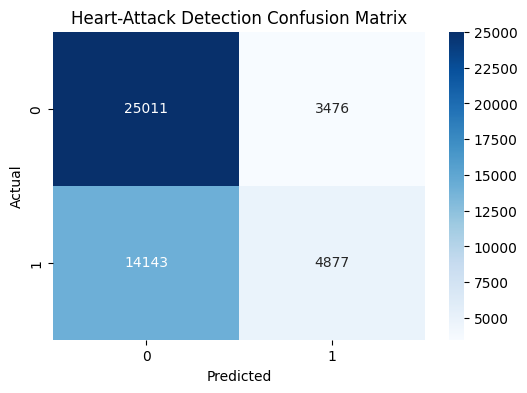

In [21]:
# DETAILED EVALUATION
target_class = pipeline.classes_  # dynamic email classes

print("--- Basic Metrics ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.2f}")
# pos_label is needed for binary classification metrics
print(f"Precision: {precision_score(y_test, y_pred, pos_label=1):.2f}")
print(f"Recall:    {recall_score(y_test, y_pred, pos_label=1):.2f}")
print(f"F1-Score:  {f1_score(y_test, y_pred, pos_label=1):.2f}")

print("\n--- Detailed Classification Report ---")
# Provides breakdown for every class
print(classification_report(y_test, y_pred))

print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred, labels=target_class)
print(cm)

# Optional: Visualizing the Confusion Matrix
# This makes it much easier to see where the model is failing
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=target_class, yticklabels=target_class, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Heart-Attack Detection Confusion Matrix')
plt.show()